# **Content**
## **Task I: Sentiment Analysis**
### **Steps:**
1. Overview of the Data and General Strategy
2. Data Analysis Preprocessing
3. Train and Evaluate Multinomial Naïve Bayes Model
4. Train and Evaluate Logistic Regression Model
5. Train and Evaluate Random Forest Model
6. Tokenize Data
7. Train and Evaluate Long Short-Term Memory (LSTM) Model
8. Evaluation of Chosen Models


## **Task II: Convolutional Neural Network**
### **Steps:**
1. Overview of the Data and General Strategy
2. Load and Alter Data From CIFAR-10
3. Load Pre-Trained VGG16, and Build and Train Model
4. Classify New Images
5. Evaluation of Model



# **Task I: Sentiment Analysis**

## **Overview of the Data and General Strategy**


### **Overview of Data:**
The dataset `Hotel_Reviews.csv` contains over 500,000 hotel reviews. Key columns containing significant information include:

* **Hotel_Name**: The name of the hotel
* **Average_Score**: The average rating of the hotel
* **Reviewer_Score**: The score assigned by the reviewer to the hotel
* **Negative_Review**: The negative feedback provided by the reviewer
* **Positive_Review:** The positive feedback provided by the reviewer
* **Review_Total_Negative_Word_Counts**: The total word count in the negative review
* **Review_Total_Positive_Word_Counts**: The total word count in the positive review
* **Total_Number_of_Reviews**: The total number of reviews for the hotel

Notably, reviewers were instructed to provide *both* a positive and a negative feedback for the hotel. If either reviews were not provided, it was recorded as 'No Positive' or 'No Negative'. This distinction will be important when constructing our training dataset.


### **General Strategy Explanation:**
For sentiment analysis, we selected four models:

* **Naïve Bayes** and **Logistic Regression**: These are fast and less resource-intensive than the others. However, they lack the ability to capture non-linear relationships and contectual depth iin text.
* **Random Forest**: Instead of using a single descision tree, we chose this ensamble method to reduce overfitting while maintaining the strong performance.
* **Long Short-Term Memory (LSTM)**: As our neural network model, we will use LSTM. LSTM is designed to capture sequential patterns and context in text, making it ideal for understanding nuanced sentiment.

This selection allows us to compare simple, interpretable models with more complex, context-aware ones. For all the models we will provide a Classification Report, and at the end, we will provide a Confusion Matrix for all the model to compare them.

### **Aim for Results:**
Our goal in this part is to achieve the following thresholds:

* **Accuracy:** > 80%
* **Precision:** > 75%
* **Recall:** > 75%
* **F1-Score:** > 75%



### **Challanges in Data Processing:**
The dataset in `Hotel_Reviews.csv` exhibits an uneven distribution if reviewer scores:

* Reviews with `Reviewer_Score >= 6`: 463,231
* Reviews with `Reviewer_Score < 6`: 52,507

This imbalance may lead our models to achieve high accuracy while still underperforming in real-world applications. A model trained on this data is likely to be biased towards the majority class.

Despite the imbalance, our evaluations indicate that while the models perform better on positive reviews, they still retain acceptable precision for negative ones. 


## **Data Analysis Preprocessing**


We begin by creating a variable called `cleaned_df`, which will retain only the most relevant columns: `Negative_Review`, `Positive_Review`, and `Reviewer_Score`. Our goal is to train a model that can detpredictermine the sentiment of a review based solely on text, and we believe that the associated reviwer score is the only necessary information for sentiment classification in our training data.

We will categorize review scores above 6 as positive and those below 6 as negative. This classification will allow us to create a new column named 'Reviews'. In this column, we will retain the review corresponding to the reviewer score - if the reviewer score is greater than 6, we will keep the positive review; otherwise, we will keep the negative review. This approach is essential because reviewers were asked to provide both types of feedback regardless of their overall score. Consequently, we may encounter instances where reviewers expressed significant dissatisfaction with the hotel, wrote extensive negative reviews, and included shorter negative 'warning words' in the positive feedback. Such cases could complicate the model's ability to accurately determine sentiment, as positive reviews might contain elements of negative feedback.

Once the `Reviews` column is creates, we will streamline the dataset further by keeping only the `Reviews` and `Reviewer_Score` columns in the final `cleaned_df`.

An important point is that this new dataframe will be split into training and test sets. Following this, we will only test the models on providing sentiment value for the reviews we believe to be genuinely connected with the given sentiment value. While this means that the model is not tested on all reviews, we believe that this approach provides a more accurate picture of how the model will perform in judging the sentiment of reviews from other datasets as well.



### **Steps:**
1. Select relevant columns
2. Label data
3. Data pre-processing
4. Vectorization
5. Split data into training and test sets

In [3]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('hotel_reviews.csv')

# ========= STEP 1: Select relevant columns ========== #

# Select only the necessary columns for sentiment analysis
cleaned_df = df[['Negative_Review', 'Positive_Review', 'Reviewer_Score']]

# Drop rows with missing values to ensure data consistency
cleaned_df = cleaned_df.dropna()


# ========== STEP 2: Label data ========== #

# Create a new column 'Sentiment' based on the reviewer score:
# Reviewer_Score >= 6   -->   Sentiment = 1 (Positive)
# Reviewer_Score < 6    -->   Sentiment = 0 (Negative)
cleaned_df['Sentiment'] = np.where(cleaned_df['Reviewer_Score'] >= 6, 1, 0)

# Create a unified 'Review' column:
# If Sentiment == 1   -->   add 'Positive_Review'
# If Sentiment == 0   -->   add 'Negative_Review'
cleaned_df['Review'] = cleaned_df['Positive_Review'].where(cleaned_df['Sentiment'] == 1, cleaned_df['Negative_Review'])

# Keep only relevant columns in dataframe
cleaned_df = cleaned_df[['Review', 'Sentiment']]


# ========== STEP 3: Data Preprocessing ========== #

# Remove default placeholder values ('No Positive' or 'No Negative')
cleaned_df = cleaned_df[~cleaned_df['Review'].isin(['No Positive', 'No Negative'])]

# Convert all text to lowercase for uniform processing
cleaned_df['Review'] = cleaned_df['Review'].str.lower()

# Remove punctuation to standardize text
cleaned_df['Review'] = cleaned_df['Review'].str.replace('[^\w\s]', '', regex=True)

print("Processed Data: \n", cleaned_df.head())


<>:41: SyntaxWarning: invalid escape sequence '\w'
<>:41: SyntaxWarning: invalid escape sequence '\w'
/var/folders/f3/qg9tldy94ns7zvqbdyv396dc0000gn/T/ipykernel_4471/1824694954.py:41: SyntaxWarning: invalid escape sequence '\w'
  cleaned_df['Review'] = cleaned_df['Review'].str.replace('[^\w\s]', '', regex=True)


ModuleNotFoundError: No module named 'pandas'

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

# ========== Step 4: Vectorization ========== #

# Initialize CountVectorizer with:
# - `min_df=5` : Ignore words that appear in fewer than 5 reviews
# - `stop_words='english'` : Remove common English stop words
vectorizer = CountVectorizer(min_df=5, stop_words='english')

# Transform the 'Review' column into a numerical feature matrix (bag-of-words representation)
X = vectorizer.fit_transform(cleaned_df['Review'])

# Target variable (Sentiment)
y = cleaned_df['Sentiment']

# Display dataset dimension after vectorization
print("Vectorized Data Shape: \n", X.shape)
# Samples == Reviews
print(" Samples: ", X.shape[0])
# Features == Unique words / Tokens
print(" Features: ", X.shape[1], "\n")

# ========== Step 5: Split data into training and test sets ========== #

# Split the data into 80% training and 20% test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display train-test split information
print("Training ans Testing Sets: ")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape, "\n")

# ========= Feature Information ========== #

# Extract feature (word) names from the vectorizer
feature_names = vectorizer.get_feature_names_out()

print("Number of features:", len(feature_names))
print("First 10 features:", feature_names[:10])
print("Features 10,010 to 10,030:", feature_names[10010:10030])
print("Every 1,000th feature:", feature_names[::1000])


Vectorized Data Shape: 
 (490312, 15818)
 Samples:  490312
 Features:  15818 

Training ans Testing Sets: 
X_train shape: (392249, 15818)
X_test shape: (98063, 15818)
y_train shape: (392249,)
y_test shape: (98063,) 

Number of features: 15818
First 10 features: ['00' '000' '001' '002' '003' '004' '007' '00am' '00h' '00hrs']
Features 10,010 to 10,030: ['oslo' 'osman' 'ostentatious' 'osteria' 'ot' 'otel' 'othe' 'otherside'
 'ott' 'ottimo' 'ottoman' 'ou' 'oud' 'ought' 'ould' 'ourself' 'ouside'
 'oustanding' 'outage' 'outcome']
Every 1,000th feature: ['00' 'alround' 'bistro' 'churches' 'currently' 'eifel' 'foor' 'hinge'
 'knowlegable' 'mere' 'orla' 'professionnal' 'riverboat' 'smill' 'tarik'
 'urquinaona']


## **Train and Evaluate Multinomial Naïve Bayes Model**

The **Multinommial Naïve Bayes** model is a simple yet powerful algorithm commonly used for tasks such as sentiment analysis. It is suitable for large datasets, and due to its probabilistic nature, it often works well with sentiment analysis. Based on Bayes' Theorem, it assumes that each word in a review contributes independently to the overall sentiment. 

This assumption allows the model to be computationally efficient and fast to train. However, the assumption of feature independence means that it ignores contextual relationships between words. It relies on word frewuency rather than word order.

In the following section, we will train and evaluate the model, using classification report.


In [4]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

#Initialize and train the Multinomial Naïve Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Predict sentiment labels for the test set
y_pred_nb = nb_model.predict(X_test)

# ========== Model Performance Metrics ========== #

# Overall accuracy
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb), "\n")
print("=" * 55)

# Detailed classification report
print("\nNaive Bayes Classification Report:\n", classification_report(y_test, y_pred_nb))
print("=" * 55)


Naive Bayes Accuracy: 0.9678879903735353 


Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.86      0.85     10235
           1       0.98      0.98      0.98     87828

    accuracy                           0.97     98063
   macro avg       0.91      0.92      0.92     98063
weighted avg       0.97      0.97      0.97     98063



The Naïve Bayes model demonstrates strong overall performance in sentiment analysis, surpassing our target metrics. It achieved an accuracy of 96.79% on a dataset of 98,063 samples. For positive sentiment (class 1), the model performs especially well, with high precision and recall, resulting in an F1-score of 0.98. However, it struggles slightly more with negative sentiment (class 0), where the F1-score drops to 0.85, indicating that the model is less consistent in identifying negative reviews.

Despite this imbalance, the macro-averaged precision, recall, and F1-score remain high—0.91, 0.92, and 0.92, respectively—showing that the model handles both classes reasonably well. While it clearly excels at recognizing positive sentiment, the performance on negative reviews is still strong enough to make Naïve Bayes a reliable baseline for sentiment classification tasks.

## **Train and Evaluate Logistic Regression Model**

The Logistic Regression model is a widely used and interpretable algorithm for binary classification tasks. It estimates the probability that a given input belongs to a particular class by fitting a linear decision boundary. Like Naïve Bayes, Logistic Regression performs well on large datasets and is fast to train.

Unlike Naïve Bayes, Logistic Regression does not assume independence between features, which is a slight advatage when capturing relationships among words. However, it still treats text as a bag of words, and does not account for word ordet or deeper lingustic context. It relies on the presence and weight of individual words to make prediction, which still makes it effective for many sentiment classification tasks

In the following section, we will train and evaluate the model using a classification report to assess its performance.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Initialize ad train the Logistic Regression model
lg_model = LogisticRegression(class_weight='balanced')
lg_model.fit(X_train, y_train)

# Predict sentiment labels for the test set
y_pred_lg = lg_model.predict(X_test)

# ========== Model Performance Metrics ========== #

# Overall accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lg), "\n")
print("=" * 55)


# Detailed classification report
print("Logistic Regression Classification Report:\n", classification_report(y_test, y_pred_lg))
print("=" * 55)


Logistic Regression Accuracy: 0.9521939977361492 

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.95      0.81     10235
           1       0.99      0.95      0.97     87828

    accuracy                           0.95     98063
   macro avg       0.85      0.95      0.89     98063
weighted avg       0.96      0.95      0.96     98063



The Logistic Regression model shows solid performance on the sentiment analysis task, with an overall accuracy of 95.22% on 98,063 samples. It performs particularly well on positive sentiment (class 1), achieving an F1-score of 0.97, while performance on negative sentiment (class 0) is lower, with an F1-score of 0.81. Like the Naïve Bayes model, it is more reliable at identifying positive reviews but struggles more with negative ones.

The macro-averaged precision, recall, and F1-score are 0.85, 0.95, and 0.89, reflecting fairly balanced performance across both classes. Weighted averages are similarly strong, with scores of 0.96, 0.95, and 0.96. While Logistic Regression slightly underperforms Naïve Bayes on overall accuracy and positive sentiment, it achieves better recall, making it a competitive and interpretable model for this task.

### Coefficient Matrix

To compare the Naïve Bayes and Logistic Regression models, we examine how individual words influence sentiment classification using two feature importance graphs.

The first graph shows log-odds from Naïve Bayes, highlighting words most indicative of positive or negative sentiment. The second graph displays Logistic Regression coefficients, where positive values increase the likelihood of positive sentiment and negative values indicate the opposite.

By comparing these two graphs, we can see how the Naïve Bayes and Logistic Regression models interpret the same data differently, providing insights into their distinct approaches to sentiment analysis.


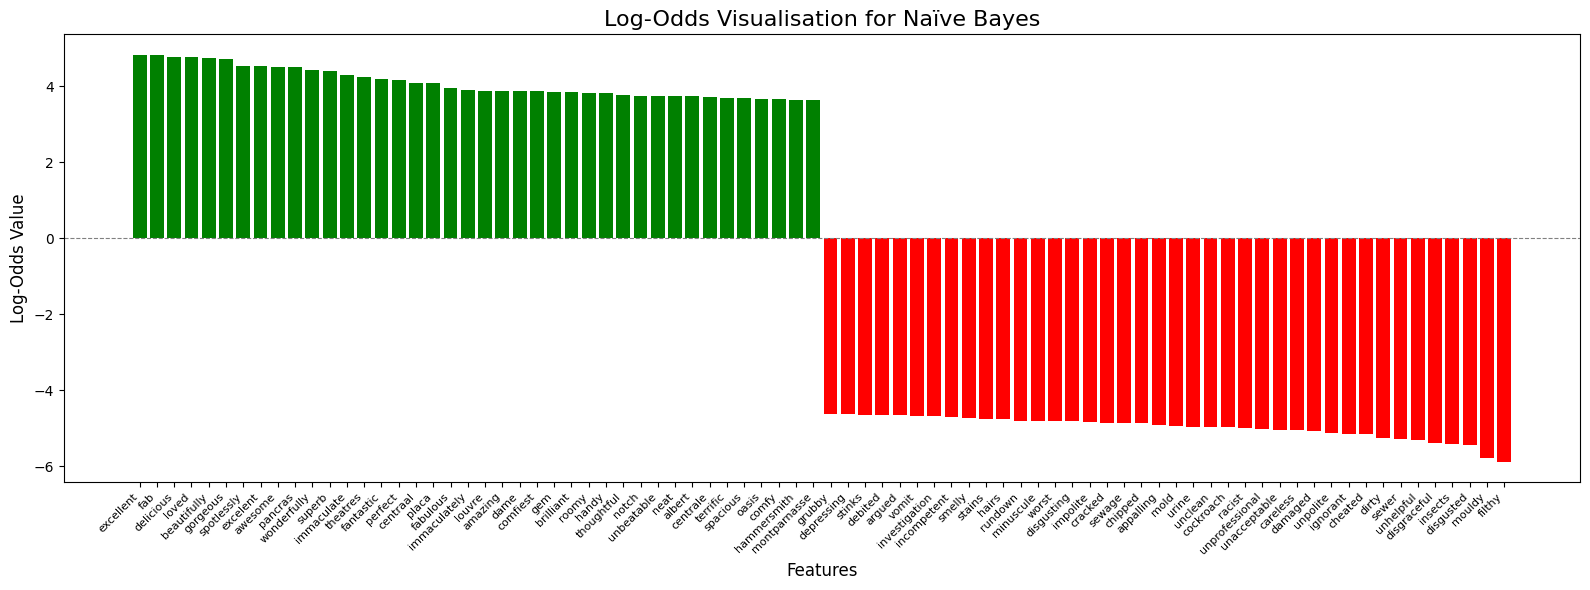

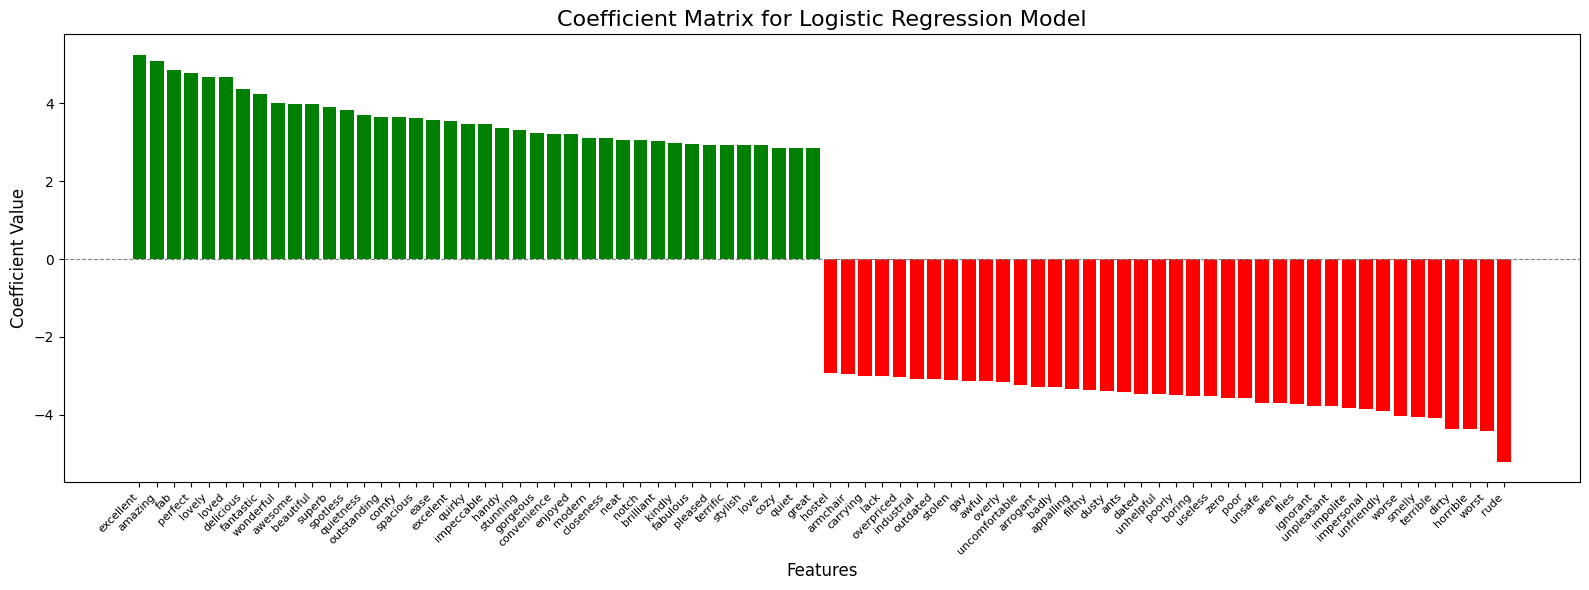

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_feature_importance(coef_df, title, ylabel):
    """Helper function to plot feature importance."""
    # Selecting the top 40 and bottom 40 features
    top_40 = coef_df.nlargest(40, coef_df.columns[0])
    bottom_40 = coef_df.nsmallest(40, coef_df.columns[0]).sort_values(by=coef_df.columns[0], ascending=False)

    # Combining top and bottom features for visualization
    combined_coef = pd.concat([top_40, bottom_40])

    # Visualizing the features with a bar plot
    plt.figure(figsize=(16, 6))
    colors = ['green' if coef > 0 else 'red' for coef in combined_coef[combined_coef.columns[0]]]

    # Create the bar plot
    plt.bar(combined_coef.index, combined_coef[combined_coef.columns[0]], color=colors)

    # Adding titles and labels
    plt.title(title, fontsize=16)
    plt.xlabel('Features', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.axhline(0, color='grey', lw=0.8, ls='--')  # Add a horizontal line at y=0
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()

# ========== Log-Odds Visualization for Naïve Bayes ========== #

# Extracting feature probabilities and calculating log-odds
feature_log_probs = nb_model.feature_log_prob_
feature_names = vectorizer.get_feature_names_out()

# Calculate log-odds for each feature
log_odds = feature_log_probs[1] - feature_log_probs[0] 
log_odds_df = pd.DataFrame(log_odds, index=feature_names, columns=['Log-Odds'])

# Plotting log-odds for Naïve Bayes
plot_feature_importance(log_odds_df, 'Log-Odds Visualisation for Naïve Bayes', 'Log-Odds Value')

# ========== Coefficient Matrix for Logistic Regression ========== #

# Extracting the coefficients from the logistic regression model
coefficients = lg_model.coef_[0]
coef_matrix = pd.DataFrame(coefficients, 
                           index=feature_names, 
                           columns=['Coefficient']).sort_values(by='Coefficient', ascending=False)

# Plotting coefficients for Logistic Regression
plot_feature_importance(coef_matrix, 'Coefficient Matrix for Logistic Regression Model', 'Coefficient Value')

### Sentiment Predicter

To highlight the differences between the models, we use the input phrase "Clean but scary." Naïve Bayes predicts a positive sentiment (1), likely focusing on the word "clean", while Logistic Regression predicts a negative sentiment (0), placing more weight on "scary." This example illustrates how the models interpret the same input differently based on how they weigh individual words.

In [ ]:
def predict_sentiment(review, model):
  # Transform the input review using the trained vectorizer
  review_vector = vectorizer.transform([review])

  # Predict the sentiment
  prediction = model.predict(review_vector)

  # Return the predicted sentiment label
  return prediction[0]

# Get user input and predict sentiment
user_review = input("Please enter your review: ")
sentiment_nb = predict_sentiment(user_review, nb_model)
sentiment_lg = predict_sentiment(user_review, lg_model)

# Display prediction result
print(f"The predicted sentiment for your review using the Naïve Bayes model is: {sentiment_nb}")
print(f"The predicted sentiment for your review using the Logistic Regression model is: {sentiment_lg}")

The predicted sentiment for your review using the Naïve Bayes model is: 1
The predicted sentiment for your review using the Logistic Regression model is: 0


## **Train and Evaluate Random Forest Model**

The Random Forest model is an ensemble decision trees that averages their results. It’s a powerful and flexible model that can handle complex, non-linear relationships in the data, making it well-suited for classification tasks like sentiment analysis. By combining the outputs of many slightly different trees, Random Forest reduces the risk of overfitting compared to using a single decision tree.

Unlike linear models such as Logistic Regression, Random Forest can capture interactions between words without requiring explicit feature engineering. However, it still operates on vectorized input and does not account for word order or sequential dependencies in text. While it typically requires more computational resources than simpler models, it often yields strong performance. 

In the following section, we will train and evaluate the model using a classification report to analyze its precision, recall, and overall effectiveness in sentiment classification.



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100,      # number of trees in the forest
                                  max_depth=10,          # maximum depth of each tree
                                  class_weight='balanced', # ajdust weights, giving more importance to minority classes
                                  random_state=42)
rf_model.fit(X_train, y_train)

# Predict sentiment labels for test set
y_pred_rf = rf_model.predict(X_test)

# ========== Model Performance Metrics ========== #

# Overall accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf), "\n")
print("=" * 55)

# Detailed classification report
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))
print("=" * 55)

Random Forest Accuracy: 0.9466873336528558 

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.83      0.76     10235
           1       0.98      0.96      0.97     87828

    accuracy                           0.95     98063
   macro avg       0.84      0.89      0.87     98063
weighted avg       0.95      0.95      0.95     98063



The Random Forest model performs well on sentiment analysis, with an overall accuracy of 94.67% on 98,063 samples. It achieves a high F1-score of 0.97 for positive sentiment (1), but performs less effectively on negative sentiment (0), with an F1-score of 0.76—lower than both Naïve Bayes and Logistic Regression.

Macro-averaged precision, recall, and F1-score are 0.84, 0.89, and 0.87, while weighted averages are consistently strong at 0.95. While Random Forest handles positive sentiment well, its weaker performance on negative sentiment highlights challenges with class imbalance.

### Feature Importance

To illustrate how the Random Forest model makes decisions, we include a feature importance graph showing which words most influence its sentiment classification. Unlike Naïve Bayes and Logistic Regression, this graph doesn't assign sentiment values to words but highlights their overall impact on the model’s predictions. It offers insight into which features the model relies on most when distinguishing between positive and negative reviews.


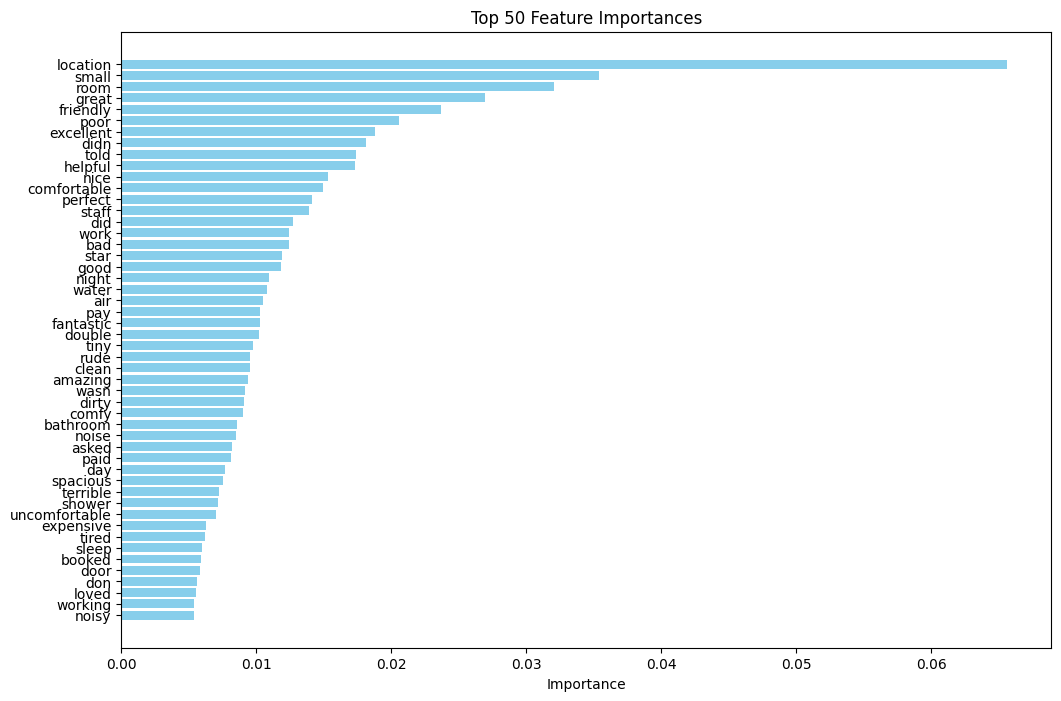

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# Get feature names
feature_names = vectorizer.get_feature_names_out()

# Get feature importances
importances = rf_model.feature_importances_

# Pair feature names with their importances
feature_importance_pairs = list(zip(feature_names, importances))

# Sort the pairs by importance
sorted_features = sorted(feature_importance_pairs, key=lambda x: x[1], reverse=True)

# Select top 50 features
top_n = 50
top_features = sorted_features[:top_n]

# Separate the feature names and their importances for plotting
top_feature_names = [feature for feature, importance in top_features]
top_importances = [importance for feature, importance in top_features]

# Step 6: Plot the feature importances
plt.figure(figsize=(12, 8))
plt.barh(top_feature_names, top_importances, color='skyblue')
plt.xlabel("Importance")
plt.title("Top 50 Feature Importances")
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature on top
plt.show()

### Sentiment Predicter

A notable finding from the feature importance analysis is that the word "location" carries much more weight than others in the Random Forest model. For example, the phrase "bad, smelly location" is classified as positive—despite containing negative words—because of "location's" strong influence. This highlights how a single dominant feature can outweigh other sentiment cues in the model’s decision-making.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

def predict_sentiment(review):
  # Transform the input review using the traines vectorizer
  review_vector = vectorizer.transform([review])

  # Predict the sentiment
  prediction = rf_model.predict(review_vector)

  # Return the predicted sentiment label
  return prediction[0]

# Get user input and predict sentiment
user_review = input("Please enter your review: ")
sentiment = predict_sentiment(user_review)

# Display prediction result
print(f"The predicted sentiment for your review is: {sentiment}")

The predicted sentiment for your review is: 1


## **Tokenize Data**

To effectively implement a Long Short-Term Memory (LSTM) model, the first crucial step is to tokenize and lemmatize the data. Tokenization involves breaking the text into smaller units, or tokens, which can be individual words or phrases. Following tokenization, lemmatization reduces each word to its base or root form. This step allows us to group words with similar meanings, such as "running," "ran," and "runs," all being reduced to "run." By combining tokenization and lemmatization, we create a more uniform representation of the text, enhancing the model's ability to understand and learn from the data. This preprocessing is vital for improving the performance of the LSTM model, as it reduces noise and ensures a focus on the underlying semantic meaning of the text.

In [ ]:
import nltk
import pandas as pd
from nltk.corpus import stopwords

# ======= Data Preprocessing for Lemmatization ======= #

# Creating a set of English stopwords
stop_words = set(stopwords.words('english'))

# Removing stopwords from the 'Review' column in the dataset
data = cleaned_df.copy()  # Create a copy of the cleaned DataFrame
data['Review'] = data['Review'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))

# Initialising a whitepsace tokeniser to split the text into words
w_tokenizer = nltk.tokenize.WhitespaceTokenizer()

# Initilaising a WordNet lemmatiser to reduce words into their base forms
lemmatizer = nltk.stem.WordNetLemmatizer()


def lemmatize_text(text):
    st = ""             # Initialise empty string to store lemmatised text
    for w in w_tokenizer.tokenize(text):            # Tokenise the input text
        st = st + lemmatizer.lemmatize(w) + " "     # Lemmatise each word and append to string
    return st

# Apply lemmatization to the 'Review' column
data['Review'] = data.Review.apply(lemmatize_text)

# Print the first 10 lemmatized reviews
print(data['Review'].head(10))



0     angry made post available via possible site us...
1     real complaint hotel great great location surr...
2     location good staff ok cute hotel breakfast ra...
3     room dirty afraid walk barefoot floor looked c...
4           amazing location building romantic setting 
5     good restaurant modern design great chill plac...
6     cleaner change sheet duvet everyday made bed a...
7     good location set lovely park friendly staff f...
9     room big enough bed good breakfast food servic...
10    room stunningly decorated really spacious top ...
Name: Review, dtype: object


In [11]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf

# ========== Prepare Date ======== #

# Extract reviewes and sentiment labels
reviews = data['Review'].values
labels = data['Sentiment'].values

# Encode the sentiment labes (1 = Positive, 0 = Negative)
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labels)

# Split data into training and testing sets, maintaining the class distribution
train_sentences, test_sentences, train_labels, test_labels = train_test_split(
    reviews,                    # The input data ('Reviews)
    encoded_labels,             # The corresponding labels
    test_size=0.2,              # Allocate 20% of the dataset to the test set
    stratify=encoded_labels,    # Maintain the same proportion of classes/labels in both training and testing sets
    random_state=42
)

# ========== Define Hyperparametres ========= #

vocab_size = 2000              # Number of words to consider for the vocabulary
oov_tok = 'OOV'                # Token used for out-of-vocabulary words
embedding_dim = 100            # Dimensionality of the embedding layer
max_length = 20                # Maximum length for padding
padding_type='post'            # Padding method: 'post' --> adding padding after the sequence
trunc_type='post'              # Truncation method 'post' --> truncates sequences after the max lenght
num_epochs = 15                # Number of training epochs
batch_size = 128               # Batch size for training
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                  patience=3,
                                                  restore_best_weights=True)


# ======== Tokenization ======= #

# Initialize the tokenizer with the specified vocabulary size and OOV token
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words = vocab_size, oov_token=oov_tok)

# Fit the tokenizer on the training sentences to learn the vocabulary
tokenizer.fit_on_texts(train_sentences)

# Convert the training and testing sentences into sequences of integers
train_sequences = tokenizer.texts_to_sequences(train_sentences)
test_sequences = tokenizer.texts_to_sequences(test_sentences)

# ========= Padding Sequences ======== #

# Pad the training sequences to ensure they all have the same length
  # 'padding='post'' --> zeros will be added to the end of the sequences
  # 'maxlen=max_length' --> maximum length of the sequences; longer sequences will be truncated
train_padded = tf.keras.preprocessing.sequence.pad_sequences(train_sequences, padding='post', maxlen=max_length)

# Pad the testing sequences in the same way as the training sequences
  # This ensures that the model receives input of consistent shape during evaluation
test_padded = tf.keras.preprocessing.sequence.pad_sequences(test_sequences, padding='post', maxlen=max_length)

# Output the shape of the padded sequence for validation
print(f"Training data shape: {train_padded.shape}")
print(f"Testing data shape: {test_padded.shape}")



Training data shape: (392249, 20)
Testing data shape: (98063, 20)


## **Train and Evaluate LSTM Model**

Neural networks are better at capturing non-linear relationships and contextual clues. Our aim in this part is to create a model that captures some contextual clues. The Long Short-Term Memory (LSTM) model is a type of recurrent neural network (RNN) designed to handle sequential data, making it particularly well-suited for natural language processing tasks like sentiment analysis. Unlike traditional models, LSTM can learn from the order of words and retain contextual information across long text sequences. This makes it possible for the model to capture patterns such as negation and nuanced phrases that simpler models likely miss.

LSTMs are more complex and computationally intensive than the other models, but they often perform better on text classification tasks, especially when trained on sufficiently large and representative datasets. Their ability to model context gives them a distinct advantage in understanding real-world reviews where sentiment is not always tied to individual words. 

In the following section, we will train and evaluate the model using a classification report to analyze its precision, recall, and overall effectiveness in sentiment classification.


In [12]:
from sklearn.utils import class_weight

# lstm_model: Sequential model for stacking layers
  ## Embedding layer:      --> converts word indices to dense vectors
  ## Bidirectional LSTM:   --> process sequences in both directions, returns full sequence
  ## Dropout layer:        --> randomly drops 50% of neurons to prevent overfitting
  ## Bidirectional LSTM:   --> process sequence in both direction, returns last output
  ## Dropout layer:        --> randomly drops 50% of neurons to prevent overfitting
  ## Dense layer:          --> fully connected layer with 8 units and ReLu activation
  ## Output layer:         --> single unit with sigmoid activation for binary classification
lstm_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, embedding_dim),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=True)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(16)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

#lstm_model.compile
  ## Loss funtion:       --> binary cross-entropy for binary classification
  ## Optimizer:          --> Adam with a learning rate of 0.001
  ## Metrics:            --> tracks accuracy during training and evaluation
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Build model with variable batch size that accepts sequences of length 'max_length'
lstm_model.build(input_shape=(None, max_length))

# Print summary of model architecture
lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 100)        │       200,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 20, 64)         │        34,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 32)             │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,689 (955.82 KB)

 Trainable params: 244,689 (955.82 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Compute class weights to address class imbalance in the training data
  # 'balanced'       --> automatically adjusts weights inversely proportional to class frequencies
  # 'classes=np.unique(train_labels)' --> specifies the unique classes in the training labels
  # 'y=train_labels' --> provides the actual labels to compute the weights
class_weights = class_weight.compute_class_weight('balanced',
                                                  classes=np.unique(train_labels),
                                                  y=train_labels)
# Create a dictionary to map class indices to their corresponding weights
class_weights = {0: class_weights[0],
                 1: class_weights[1]}
# Train the LSTM model using the padded training sequences and labels
  # train_paddel       --> input for training data
  # train_labels       --> corresponding labels for training data
  # epochs             --> number of epochs to train the model
  # batch_size         --> number of samples per gradient update
  # validation_split   --> use 10% of training data for validation
  # class_weight       --> apply class weights to handle class imbalance
  # callbacks          --> early stopping to prevent overfitting
  # verbose            --> 1: progress will be displayes during training
history = lstm_model.fit(train_padded,
                         train_labels,
                         epochs=num_epochs,
                         batch_size=batch_size,
                         validation_split=0.1,
                         class_weight=class_weights,
                         callbacks=[early_stopping],
                         verbose=1
                         )


Epoch 1/15
2758/2758 ━━━━━━━━━━━━━━━━━━━━ 61s 20ms/step - accuracy: 0.9123 - loss: 0.2193 - val_accuracy: 0.9418 - val_loss: 0.1450
Epoch 2/15
2758/2758 ━━━━━━━━━━━━━━━━━━━━ 83s 21ms/step - accuracy: 0.9444 - loss: 0.1341 - val_accuracy: 0.9458 - val_loss: 0.1246
Epoch 3/15
2758/2758 ━━━━━━━━━━━━━━━━━━━━ 63s 23ms/step - accuracy: 0.9456 - loss: 0.1283 - val_accuracy: 0.9515 - val_loss: 0.1209
Epoch 4/15
2758/2758 ━━━━━━━━━━━━━━━━━━━━ 60s 22ms/step - accuracy: 0.9482 - loss: 0.1223 - val_accuracy: 0.9479 - val_loss: 0.1225
Epoch 5/15
2758/2758 ━━━━━━━━━━━━━━━━━━━━ 56s 20ms/step - accuracy: 0.9494 - loss: 0.1177 - val_accuracy: 0.9533 - val_loss: 0.1102
Epoch 6/15
2758/2758 ━━━━━━━━━━━━━━━━━━━━ 64s 23ms/step - accuracy: 0.9526 - loss: 0.1081 - val_accuracy: 0.9507 - val_loss: 0.1249
Epoch 7/15
2758/2758 ━━━━━━━━━━━━━━━━━━━━ 59s 21ms/step - accuracy: 0.9539 - loss: 0.1047 - val_accuracy: 0.9520 - val_loss: 0.1195
Epoch 8/15
2758/2758 ━━━━━━━━━━━━━━━━━━━━ 60s 22ms/step - accuracy: 0.9554 -

In [14]:
from sklearn.metrics import classification_report

# ======== Model Evaluation ========= #

# Predict sentiment labels for the test data
y_pred_lstm = lstm_model.predict(test_padded)

# Get labels based on probability 1 if p>= 0.5 else 0
pred_labels = (y_pred_lstm >= 0.5).astype(int).flatten()

# Accuracy
accuracy = accuracy_score(test_labels, pred_labels)
print("Accuracy of prediction on test set: ", accuracy)
print("=" * 55)

# Generate classification report
print("LSTM Classification Report:\n", classification_report(test_labels, pred_labels))
print("=" * 55)


3065/3065 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step
Accuracy of prediction on test set:  0.9503686405677982
LSTM Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.93      0.80     10233
           1       0.99      0.95      0.97     87830

    accuracy                           0.95     98063
   macro avg       0.84      0.94      0.88     98063
weighted avg       0.96      0.95      0.95     98063



The Long Short-Term Memory (LSTM) model achieves strong performance in sentiment analysis, with an overall accuracy of 95.04% on 98,063 samples. It performs well for positive sentiment (F1-score: 0.97) but faces challenges with negative sentiment (F1-score: 0.80), similar to the Random Forest model.

Macro averages show balanced performance across classes, with precision, recall, and F1-scores of 0.84, 0.94, and 0.88. The weighted averages reinforce the model’s effectiveness, with scores of 0.96 for precision and recall, and 0.95 for F1. Despite strong results for positive sentiment, the LSTM model struggles with negative sentiment, indicating room for improvement in class imbalance.

During training, the LSTM model underwent 8 epochs (ended by `callbacks=[early_stopping]`), with the accuracy steadily improving from 91.23% in the first epoch to 95.54% by the eighth epoch. The loss also decreased significantly, indicating effective learning. Validation accuracy showed a similar upward trend, reaching a peak of 95.33% by the fifth epoch, while validation loss fluctuated but generally trended downward. These training metrics suggest that the LSTM model is effectively learning from the data, achieving strong performance on both training and validation sets. 

### Plotting Training History

In LSTM training, the steady improvement in training scores shows effective learning, but fluctuating validation scores suggest potential overfitting. This indicates that while the model performs well on training data, it struggles to generalize to unseen data.

The plot below reflects this trend: training scores steadily increase, while validation scores fluctuate, suggesting the model may not be generalizing well, potentially due to overfitting.

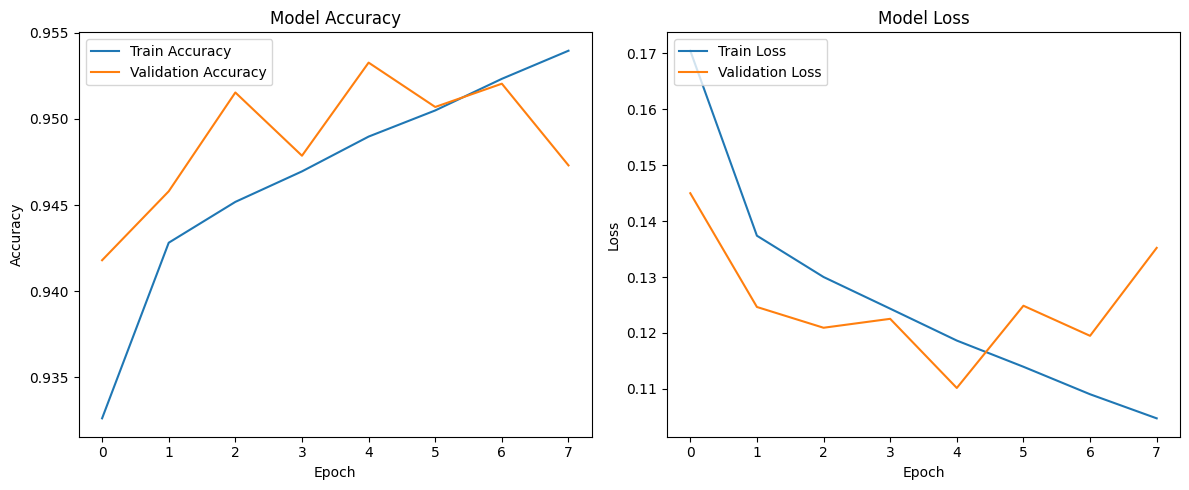

In [ ]:
# ======== Plotting Training History ========= #

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()  
plt.show() 

## **Evaluation of Chosen Models**

### Classification Reports & Confusion Matrixes


Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.86      0.85     10235
           1       0.98      0.98      0.98     87828

    accuracy                           0.97     98063
   macro avg       0.91      0.92      0.92     98063
weighted avg       0.97      0.97      0.97     98063


Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.95      0.81     10235
           1       0.99      0.95      0.97     87828

    accuracy                           0.95     98063
   macro avg       0.85      0.95      0.89     98063
weighted avg       0.96      0.95      0.96     98063


Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.83      0.76     10235
           1       0.98      0.96      0.97     87828

    accuracy                           0.95     98063
   macr

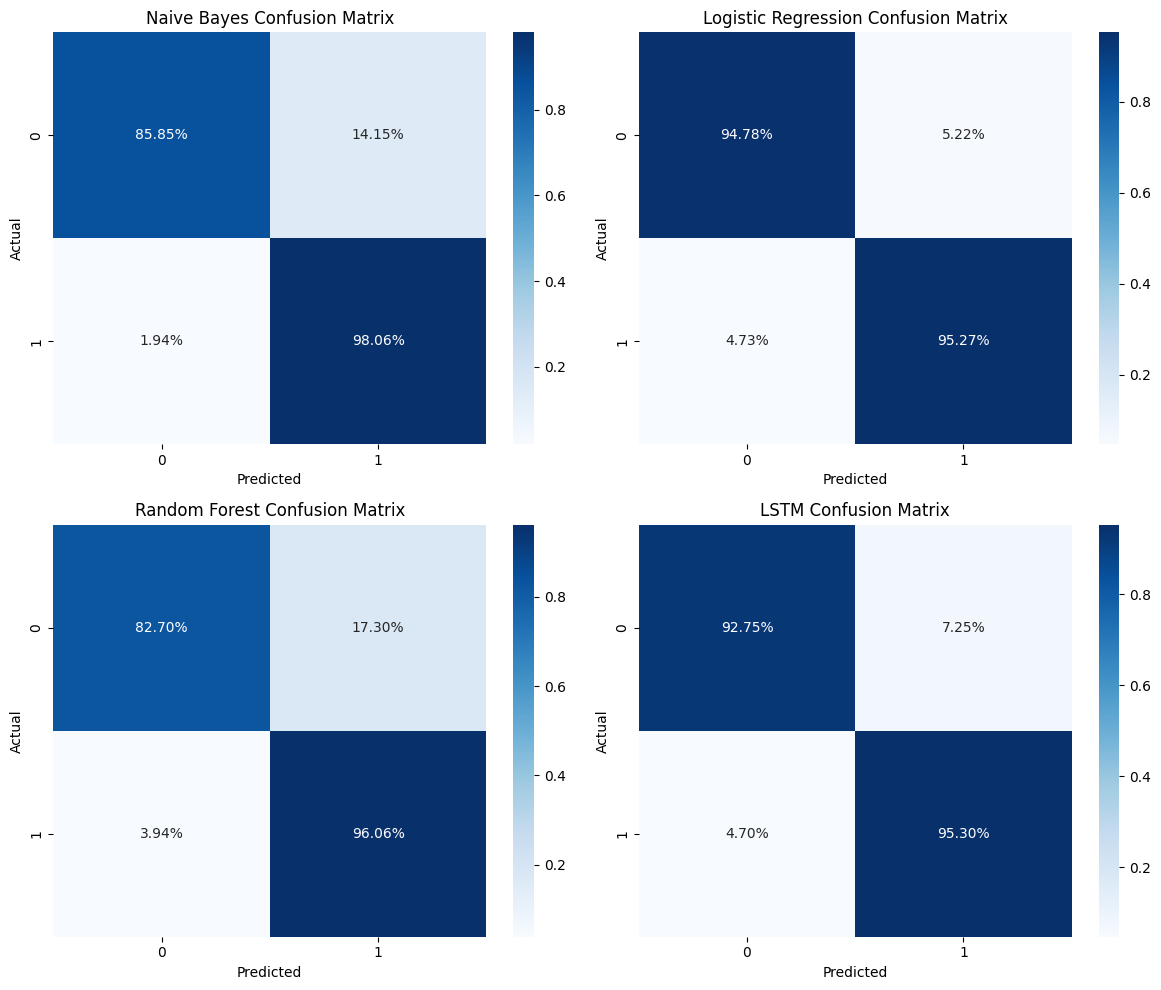

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

print("\nNaive Bayes Classification Report:\n", classification_report(y_test, y_pred_nb))
print("\nLogistic Regression Classification Report:\n", classification_report(y_test, y_pred_lg))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))
print("LSTM Classification Report:\n", classification_report(test_labels, pred_labels))

# ======= Compute confusion matrices =========

cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_lg = confusion_matrix(y_test, y_pred_lg)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_lstm = confusion_matrix(test_labels, pred_labels)

# Normalize the confusion matrices by row 
cm_nb_normalized = cm_nb.astype('float') / cm_nb.sum(axis=1)[:, np.newaxis]
cm_lg_normalized = cm_lg.astype('float') / cm_lg.sum(axis=1)[:, np.newaxis]
cm_rf_normalized = cm_rf.astype('float') / cm_rf.sum(axis=1)[:, np.newaxis]
cm_lstm_normalized = cm_lstm.astype('float') / cm_lstm.sum(axis=1)[:, np.newaxis]


# ======== Visulaize Condusion Matrixes ========

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Naive Bayes Confusion Matrix
sns.heatmap(cm_nb_normalized, annot=True, fmt='.2%', ax=axes[0, 0], cmap='Blues')
axes[0, 0].set_title('Naive Bayes Confusion Matrix')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# Logistic Regression Confusion Matrix
sns.heatmap(cm_lg_normalized, annot=True, fmt='.2%', ax=axes[0, 1], cmap='Blues')
axes[0, 1].set_title('Logistic Regression Confusion Matrix')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

# Random Forest Confusion Matrix
sns.heatmap(cm_rf_normalized, annot=True, fmt='.2%', ax=axes[1, 0], cmap='Blues')
axes[1, 0].set_title('Random Forest Confusion Matrix')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')

# LSTM Confusion Matrix
sns.heatmap(cm_lstm_normalized, annot=True, fmt='.2%', ax=axes[1, 1], cmap='Blues')
axes[1, 1].set_title('LSTM Confusion Matrix')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')

print("\nNaive Bayes Confusion Matrix:\n", cm_nb)
print("\nLogistic Regression Confusion Matrix:\n", cm_lg)
print("\nRandom Forest Confusion Matrix:\n", cm_rf)
print("\nLSTM Confusion Matrix:\n", cm_lstm)

plt.tight_layout()
plt.show()

### **Summary of Results**

The four models — Naïve Bayes, Logistic Regression, Random Forest, and Long Short-Term Memory (LSTM) — show varying performance across different metrics. Naïve Bayes excels with an impressive accuracy of 97%, achieving high precision (0.98) and recall (0.98) for positive sentiment, and an F1-score of 0.85 for negative sentiment. While it performs best for positive sentiment, it still handles negative sentiment well.

Logistic Regression, with 95% accuracy, shows high precision (0.99) for positive sentiment but lower recall (0.95), and struggles with negative sentiment, reflected by an F1-score of 0.81. Random Forest, also at 95% accuracy, follows similar trends with high precision for positive sentiment (0.98) but lower recall (0.83) for negative sentiment.

The LSTM model, also at 95% accuracy, mirrors Logistic Regression and Random Forest in terms of performance. It performs well with positive sentiment (precision 0.99) but faces challenges with negative sentiment (F1-score 0.80).

Overall, while Naïve Bayes excels at detecting positive sentiment, all models struggle with negative sentiment, indicating room for improvement in handling class imbalance.

# **Task II: Convolutional Neural Network**


## **Explanation of Data and General Plan**

### **Explanation of Data:**
CIFAR-10 is a dataset that contains 60,000 images across 10 categories, with 6,000 images in each category. For our project, we decided to focus on the 'dog' category

### **Explanation of General Plan:**

In our work with Convolutional Neural Networks (CNNs), we explored various pre-trained models to determine the best fit for our needs. We initially started with VGG16; however, since it is primarily designed for larger images (224x224), we were advised to consider alternatives. We then experimented with MobileNetV2, which is optimized for mobile and edge devices. While it was significantly faster and less resource-intensive than VGG16, its performance was not as strong. We also tried VGG19, which is even more resource-intensive than VGG16, but it yielded worse results as well. Ultimately, we returned to using VGG16.

We also explored data manipulation techniques such as oversampling dog images, undersampling non-dog images, data augmentation, and class weights. These approaches had mixed results, with some increasing accuracy but also leading to higher loss values. Ultimately, we balanced the dataset by duplicating and augmenting dog images while undersampling non-dog images.

### **Aim:**
* Accuracy: > 90%
* Loss: < 0.2
* Val_accuracy: > 85%
* Val_loss: < 0.3

### Challanges in Data Processing:
Similar to the dataset used in Task 1, the CIFAR-10 dataset is imbalanced. Initially, our model could achieve an accuracy of 0.9 simply by predicting 'not dog' for every input. To address this issue, we implemented various data manipulation strategies to improve the model's performance.

## **Load and Alter Data From CIFAR-10**

In [17]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report
import os

# ======= Load CIFAR-10 dataset ======

# x_train & x_test: Image data (num_samples, 32, 32, 3)
# y_train & y_test: Class labels (shape:(num_samples, 1), values from 0-9)
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Convert labels to binary: 1 for "dog", 0 for all others
category = 5
y_train_binary = (y_train == category).astype("int").flatten()
y_test_binary = (y_test == category).astype("int").flatten()


# ======= Alter Data =========

# Separate dog and non-dog images
dog_images = x_train[y_train_binary == 1]
non_dog_images = x_train[y_train_binary == 0]

# Initialize the ImageDataGenerator with desired augmentations
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=False,
    fill_mode='nearest'
)

# Create a duplicate list of dog_images and augment
augmented_dogs = []
for dog_image in dog_images:
    img_array = np.expand_dims(dog_image, axis=0)  # Add batch dimension

    # Generate augmented images
    for batch in datagen.flow(img_array, batch_size=1):
        augmented_dogs.append(batch[0])  # Append the augmented image
        break  # Break after one augmentation to avoid infinite loop

# Convert augmented_dogs to a numpy array
augmented_dogs = np.array(augmented_dogs)

# Combine original dog images with augmented images
combined_dogs = np.concatenate((dog_images, augmented_dogs), axis=0)

# Undersample non-dog images
num_non_dogs = len(non_dog_images)
undersample_size = len(combined_dogs)  # Set to the number of dog images
indices = np.random.choice(num_non_dogs, undersample_size, replace=False)
undersampled_nondogs = non_dog_images[indices]

# Combine the datasets
x_combined = np.concatenate((combined_dogs, undersampled_nondogs))
y_combined = np.concatenate((np.ones(len(combined_dogs)), np.zeros(len(undersampled_nondogs))))

# Shuffle the combined dataset
indices = np.arange(len(y_combined))
np.random.shuffle(indices)
x_combined = x_combined[indices]
y_combined = y_combined[indices]

# Normalize images
x_combined = x_combined / 255.0

## **Load Pre-Trained VGG16, and Build and Train Model**

In [18]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report
import os


# ====== Load VGG16 (CNN trained on ImageNet) =====

# Base model:
  # weights="imagenet"      --> loads pre-trained weights from ImageNet (what VGG16 is trained on)
  # include_top=False       --> removes fully connected layers (classifiers)
  # input_shape=(32, 32, 3) --> CIFAR-10 images are 32x32 pixels with three colour channels (RGB)
base_model = keras.applications.VGG16(weights="imagenet",
                                      include_top=False,
                                      input_shape=(32, 32, 3))
# Freeze the pre-trained convolutional layers
base_model.trainable = False

# ========= Build and Compile Model ===========

# Model:
  # base_model                     --> frozen VGG16 convolutional layers
  # GlobalAveragePooling2D()       --> converts final convolutional layer into a single feature vector
  # Dense(128, activation="relu")  --> fully connected layer with 128 neurons and ReLu activation
  # Dense(1, activation="sigmoid") --> output layer for binary classification (dog vs. not dog)
model = keras.Sequential([
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

# Compile the model:
  # optimizer="adam"           --> adaptive optimiser
  # loss="binary_crossentropy" --> use binary cross-entropy as loss function
  # metrics=["accuracy"]       --> tracks model accuracy during training
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])


# ======= Train the model ========

# x_train, y_train_binary   --> training data and labels (dog = 1, not dog = 0)
# validation_data(x_test, y_test_binary) --> evaluates models performance on test data
# epochs=n                  --> Trains n epochs
# batch_size=64             --> processes 64 images per training step
model.fit(x_combined, y_combined,
          validation_data=(x_test / 255.0, y_test_binary),
          epochs=20,
          batch_size=64)

# =========== Evaluate Model ============
y_pred = (model.predict(x_test / 255.0) > 0.5).astype("int").flatten()
print(classification_report(y_test_binary, y_pred, target_names=["Not Dog", "Dog"]))

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 137s 428ms/step - accuracy: 0.7452 - loss: 0.5068 - val_accuracy: 0.7522 - val_loss: 0.5031
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 125s 400ms/step - accuracy: 0.8107 - loss: 0.4168 - val_accuracy: 0.7926 - val_loss: 0.4389
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 126s 403ms/step - accuracy: 0.8157 - loss: 0.3989 - val_accuracy: 0.8116 - val_loss: 0.4014
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 185s 592ms/step - accuracy: 0.8275 - loss: 0.3846 - val_accuracy: 0.8205 - val_loss: 0.3815
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 200s 637ms/step - accuracy: 0.8341 - loss: 0.3701 - val_accuracy: 0.8235 - val_loss: 0.3839
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 129s 405ms/step - accuracy: 0.8351 - loss: 0.3622 - val_accuracy: 0.8185 - val_loss: 0.3955
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 125s 400ms/step - accuracy: 0.8417 - loss: 0.3529 - val_accuracy: 0.8107 - val_loss: 0.4040
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 120s 384ms/step - accuracy: 0.8511 -

## **Classify New Image**

In the following section, the model was tasked with classifying 14 new images of dogs and 4 new images of cats. As anticipated from the Classification Report, the model did not excel in this task. The classifications are illustrated below Evaluation of Model.


In [19]:
import cv2

# <====== Method for displaying and classiying images ======>

def classify_image(image_path):
  image = cv2.imread(image_path)
  # Loads image based on image_path

  # <====== Display image ======>

  # Converts copy of image to RGB, so it displays correctly
  image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  # Display and show image, without axis labels
  plt.imshow(image_rgb)
  plt.axis('off')
  plt.show()

  # <====== Classify image and make prediction ======>

  # Resizes image to 32x32 pixels to match expected input size by the model
  image = cv2.resize(image, (32, 32))
  # Normalise pixel values to the range [0,1]
  image = image / 255.0
  # Adds batch dimension to image, as the model expects this
  image = np.expand_dims(image, axis=0)

  # Model makes prediction on the image
  prediction = model.predict(image)
  print("Prediction score:", prediction[0][0])
  print("Classified as:", "Dog" if prediction[0][0] > 0.5 else "Not Dog")

## **Evaluation of Model**

### **Training Data**
The model was trained over 20 epochs to classify images of dogs and cats, demonstrating a general trend of improvement in both training and validation accuracy. Starting with an accuracy of 74.52% in the first epoch, the model achieved a final training accuracy of 90.91% and a loss of 0.2272. However, the validation accuracy fluctuated, peaking at 86.20% in the 12th epoch but ultimately ending at 76.47% by the 20th epoch. This inconsistency suggests that while the model learned effectively from the training data, it faced challenges in generalizing to unseen data.

### **Classification Report**
The Classification Report further highlights the model's performance, revealing a precision of 0.98 and a recall of 0.76 for the 'Not Dog' category, indicating strong performance in identifying non-dog images. Conversely, the model struggled with the 'Dog' category, achieving a precision of only 0.28 and a recall of 0.85, which points to difficulties in accurately classifying dog images. The overall accuracy across the dataset was 76%, with macro and weighted averages indicating a need for improvement in the model's ability to generalize across both categories.

### **Image Classification**
In a specific evaluation involving 14 new dog images and 4 new cat images, the model correctly identified 7 out of 14 dog images as 'dog' and successfully classified 2 out of 4 cat images as 'not dog'. The choice to include cat images was strategic, as they can often resemble dog images, presenting a challenge for the model. The results from this evaluation underscore the model's limitations, particularly in noisy conditions, and highlight the necessity for further refinement to enhance its accuracy and robustness in distinguishing between similar-looking categories.

### **Summary**
Overall, while the model shows promise in classifying images of dogs and cats, its performance indicates that additional training, data augmentation, or architectural adjustments may be required to improve its accuracy and generalization capabilities. Addressing these challenges will be crucial for achieving better results in real-world applications where image quality and similarity between categories can vary significantly.

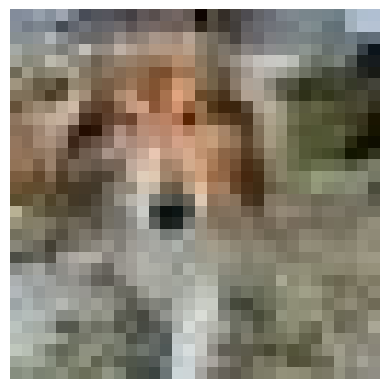

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
Prediction score: 0.89619666
Classified as: Dog


In [20]:
# Classify new image of dog
classify_image('32_hund1.jpg')

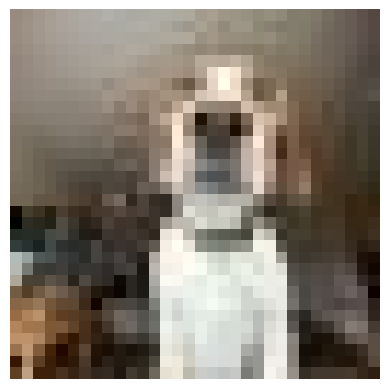

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
Prediction score: 0.76778656
Classified as: Dog


In [21]:
# Classify new image of dog
classify_image('32_hund2.jpg')

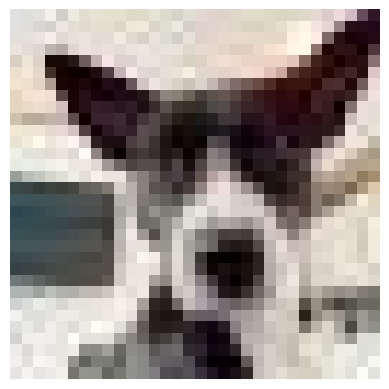

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Prediction score: 0.2913642
Classified as: Not Dog


In [22]:
# Classify new image of dog
classify_image('32_hund3.jpg')

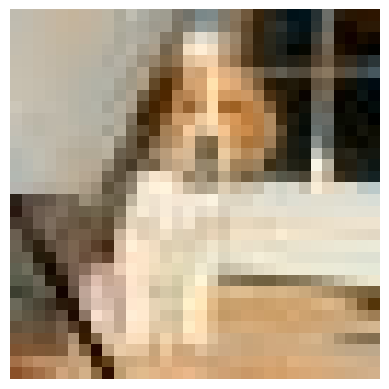

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Prediction score: 0.31897178
Classified as: Not Dog


In [23]:
# Classify new image of dog
classify_image('32_hund4.jpg')

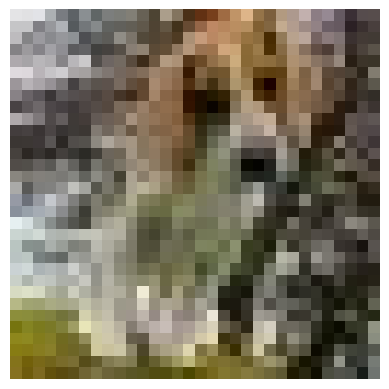

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Prediction score: 0.009637866
Classified as: Not Dog


In [24]:
# Classify new image of dog
classify_image('32_hund5.jpg')

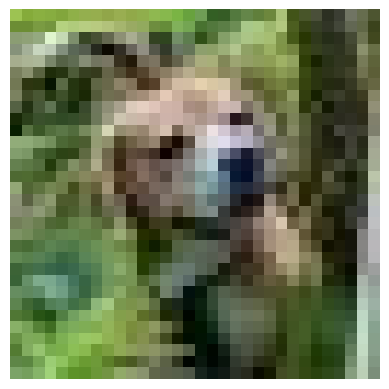

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Prediction score: 0.07813209
Classified as: Not Dog


In [25]:
# Classify new image of dog
classify_image('32_hund6.jpg')

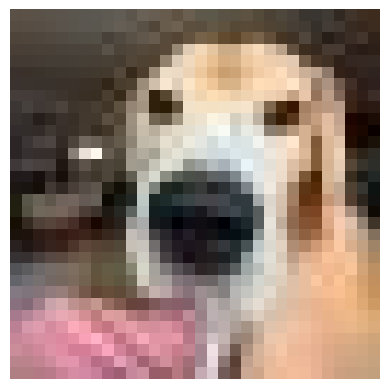

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Prediction score: 0.99997866
Classified as: Dog


In [30]:
# Classify new image of dog
classify_image('32_hund9.jpg')

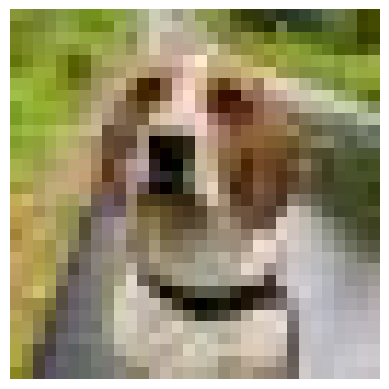

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Prediction score: 0.4130716
Classified as: Not Dog


In [31]:
# Classify new image of dog
classify_image('32_hund10.jpg')

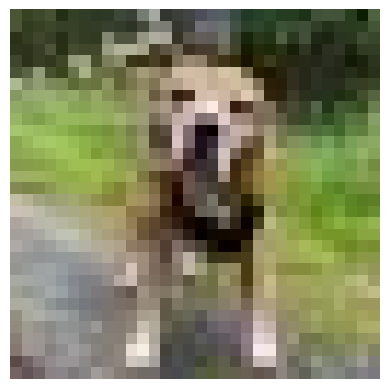

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediction score: 0.76567376
Classified as: Dog


In [32]:
# Classify new image of dog
classify_image('32_hund11.jpg')

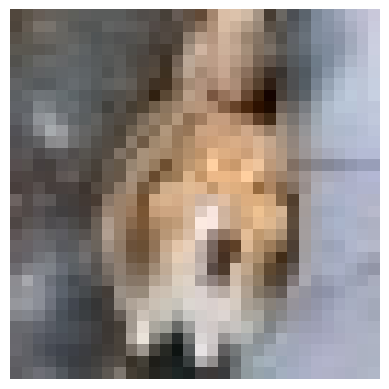

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Prediction score: 0.99036545
Classified as: Dog


In [33]:
# Classify new image of dog
classify_image('32_hund12.jpg')

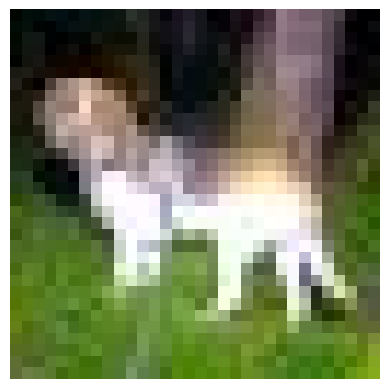

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Prediction score: 0.98253167
Classified as: Dog


In [34]:
# Classify new image of dog
classify_image('32_hund13.jpg')

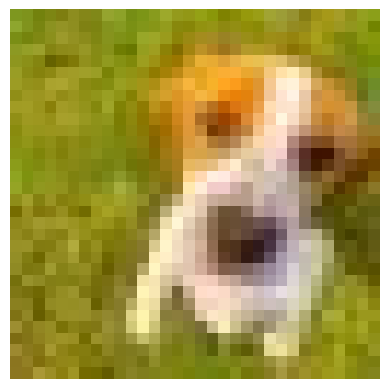

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Prediction score: 0.9996608
Classified as: Dog


In [35]:
# Classify new image of dog
classify_image('32_hund14.jpg')

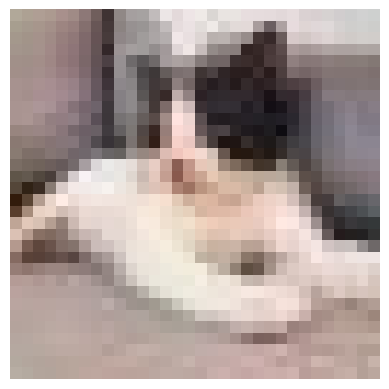

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Prediction score: 0.9403377
Classified as: Dog


In [26]:
# Classify new image of cat
classify_image('32_katt1.jpg')

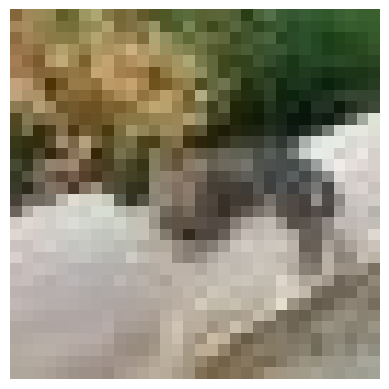

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Prediction score: 0.33950967
Classified as: Not Dog


In [27]:
# Classify new image of cat
classify_image('32_katt2.jpg')

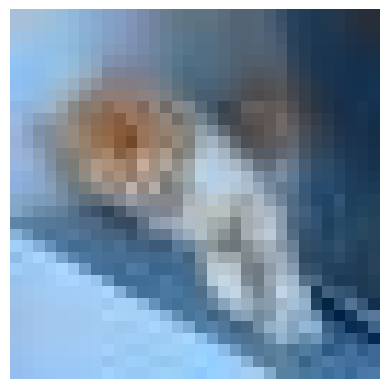

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Prediction score: 0.88545257
Classified as: Dog


In [28]:
# Classify new image of cat
classify_image('32_katt3.jpg')

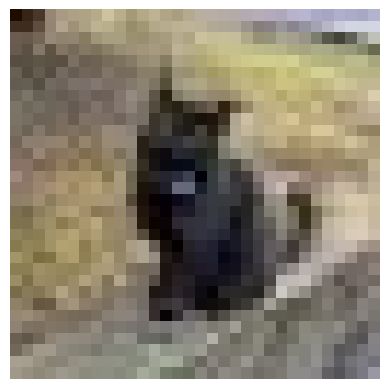

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Prediction score: 0.13925171
Classified as: Not Dog


In [29]:
# Classify new image of cat
classify_image('32_katt4.jpg')

# **Sources**
* Beaujuge, P. (2021, December 15). Classifying Images from the CIFAR10 Dataset with Pre-Trained CNNs Using Transfer Learning. *Medium*. https://medium.com/@pierre.beaujuge/classifying-images-from-the-cifar10-dataset-with-pre-trained-cnns-using-transfer-learning-9348f6d878a8
* Chollet, F. (2018). *Deep Learning with Python*. Manning Publications Co.
* GeeksforGeeks. (2024, May 13). CIFAR10 DataSet in KERAS (Tensorflow) for object recognition. *GeeksforGeeks*. https://www.geeksforgeeks.org/cifar10-dataset-in-keras-tensorflow-for-object-recognition/
* Lenko, M. (2021, December 12). Instructions for transfer learning with pre-trained CNNs. *Medium*. https://medium.com/@mikhaillenko/instructions-for-transfer-learning-with-pre-trained-cnns-203ddaefc01
* Marcelino, P. (2022, May 6). Transfer learning from pre-trained models. *Medium*. https://medium.com/data-science/transfer-learning-from-pre-trained-models-f2393f124751
* Müller, A. C., & Guido, S. (2016). *Introduction to Machine Learning with Python: A Guide for Data Scientists*. O’Reilly Media
* Lecture Notes
